In [2]:
%run "/home/nichettg/Ubuntu/Laboratorio/moduli.py"

In [3]:
titolo = "Andamento del Voltaggio"
xlabel = "t [s]"
ylabel = "$v_0 [V]$"

file_input = "dati.csv"
file_output1 = "Analisi/regressione.txt"
file_output2 = "Analisi/residui.txt"
file_output3 = "Analisi/chi.txt"
grafico_output1 = "Analisi/regressione.pdf"
grafico_output2 = "Analisi/residui.pdf"
grafico_output3 = "Analisi/chi.pdf"

### 1. Lettura

In [4]:
data = f.csv_to_dict(file_input)

incertezza_tempo = 10 * 10**(-7)

xdata = np.array([data["tempo"],
                  np.full_like(data["tempo"], incertezza_tempo)])
ydata = np.array([data["voltaggio"]/10,
                  2/100 * 2 + abs(3/100 * data["voltaggio"])])

### 2. Analisi

In [5]:
cinque_parametri = False
tre_parametri = True

Modello di regressione non lineare ai capi di C con tutti i cinque parametri.

In [6]:
if cinque_parametri:
    def modello(par, x):
        a,b,d,c,g = par
        return a/b * np.exp(- ( x - c ) / d ) * ( 1/d * np.sin(b * (x - c ) ) + b * np.cos(b * (x - c ) ) ) + g

    v0 = 45/10
    omega0 = 4.68 * 10**(5)
    t0 = 0.001
    tau0 = 10**(-5)
    voff = 0.01

    param_labels = ['v0','omega','tau','t0','voff']
    dati_iniziali = [v0,omega0,tau0,t0,voff]

Modello di regressione non lineare ai capi di C con solo tre parametri (gli offset sono fissati a zero).

In [7]:
if tre_parametri:
    def modello(par, x):
        a,b,d = par
        return a/b * np.exp(- ( x ) / d ) * ( 1/d * np.sin(b * ( x ) ) + b * np.cos(b * ( x ) ) )

    v0 = 45/10
    omega0 = 4.68 * 10**(5)
    tau0 = 10**(-5)

    param_labels = ['$v_0$','$\Omega$',r'$\tau$']
    dati_iniziali = [v0,omega0,tau0]

<>:10: SyntaxWarning: invalid escape sequence '\O'
<>:10: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_53043/2609773029.py:10: SyntaxWarning: invalid escape sequence '\O'
  param_labels = ['$v_0$','$\Omega$',r'$\tau$']


Regressione

In [8]:
anal = f.fit(xdata,ydata,modello,dati_iniziali,chi=True)

f.inizializza_output(file_output1)
gf.salva_analisi(anal, param_labels, file_output1)

Esportazione Pickle

In [9]:
gf.esporta_pickle([anal, xdata, ydata], "analisi.pkl")

Residui e Chi Quadro della Regressione

In [10]:
f.inizializza_output(file_output2)
res = f.residui(xdata,ydata,anal[:,0],modello,file_output2,titolo)

f.inizializza_output(file_output3)
chi = f.chi_quadro(xdata,ydata,anal[:,0],modello,file_output3,titolo)

### 3. Grafici

Regressione

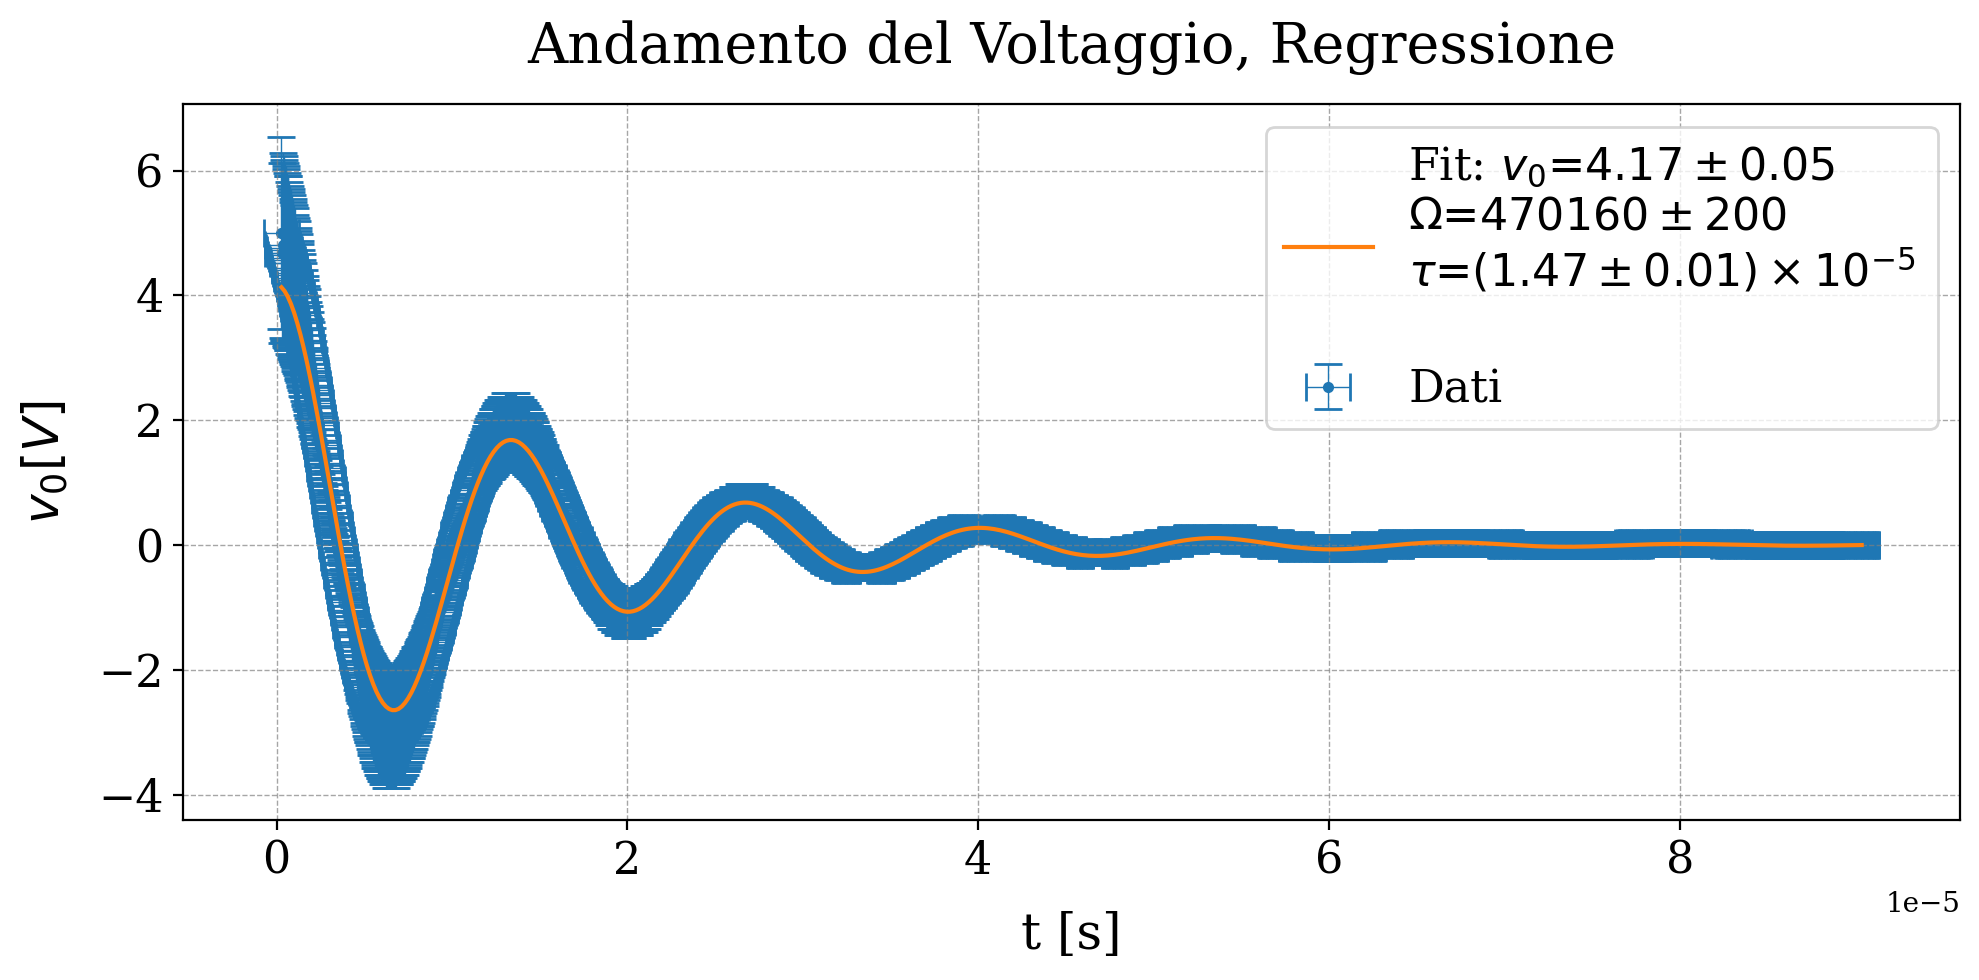

In [11]:
fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
gf.parametri_grafico(ax,titolo + ", Regressione",xlabel=xlabel,ylabel=ylabel)
# Grafico dei dati con errori
ax.errorbar(xdata[0],ydata[0],xerr=xdata[1],yerr=ydata[1],
            label="Dati", **gf.errorbar_params, color = gf.colori[0], zorder=1)
# Grafico del fit
fit_label = "Fit: " + "".join(
    f"{param_labels[i]}={gf.formatta_errore(anal[i,0],anal[i,1])}\n" for i in range(len(param_labels))
)
x_fit = np.linspace(min(xdata[0]), max(xdata[0]), 500)
ax.plot(x_fit,modello(anal[:,0],x_fit),
        label=fit_label, **gf.plot_params, color = gf.colori[1], zorder=2)

ax.legend()

gf.salva_grafico(fig,grafico_output1)

Residui e Chi Quadro Regressione

<>:14: SyntaxWarning: invalid escape sequence '\c'
<>:14: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_53043/1760285679.py:14: SyntaxWarning: invalid escape sequence '\c'
  gf.parametri_grafico(ax,titolo + r", $\chi^2$",xlabel=xlabel,ylabel="$\chi^2$")


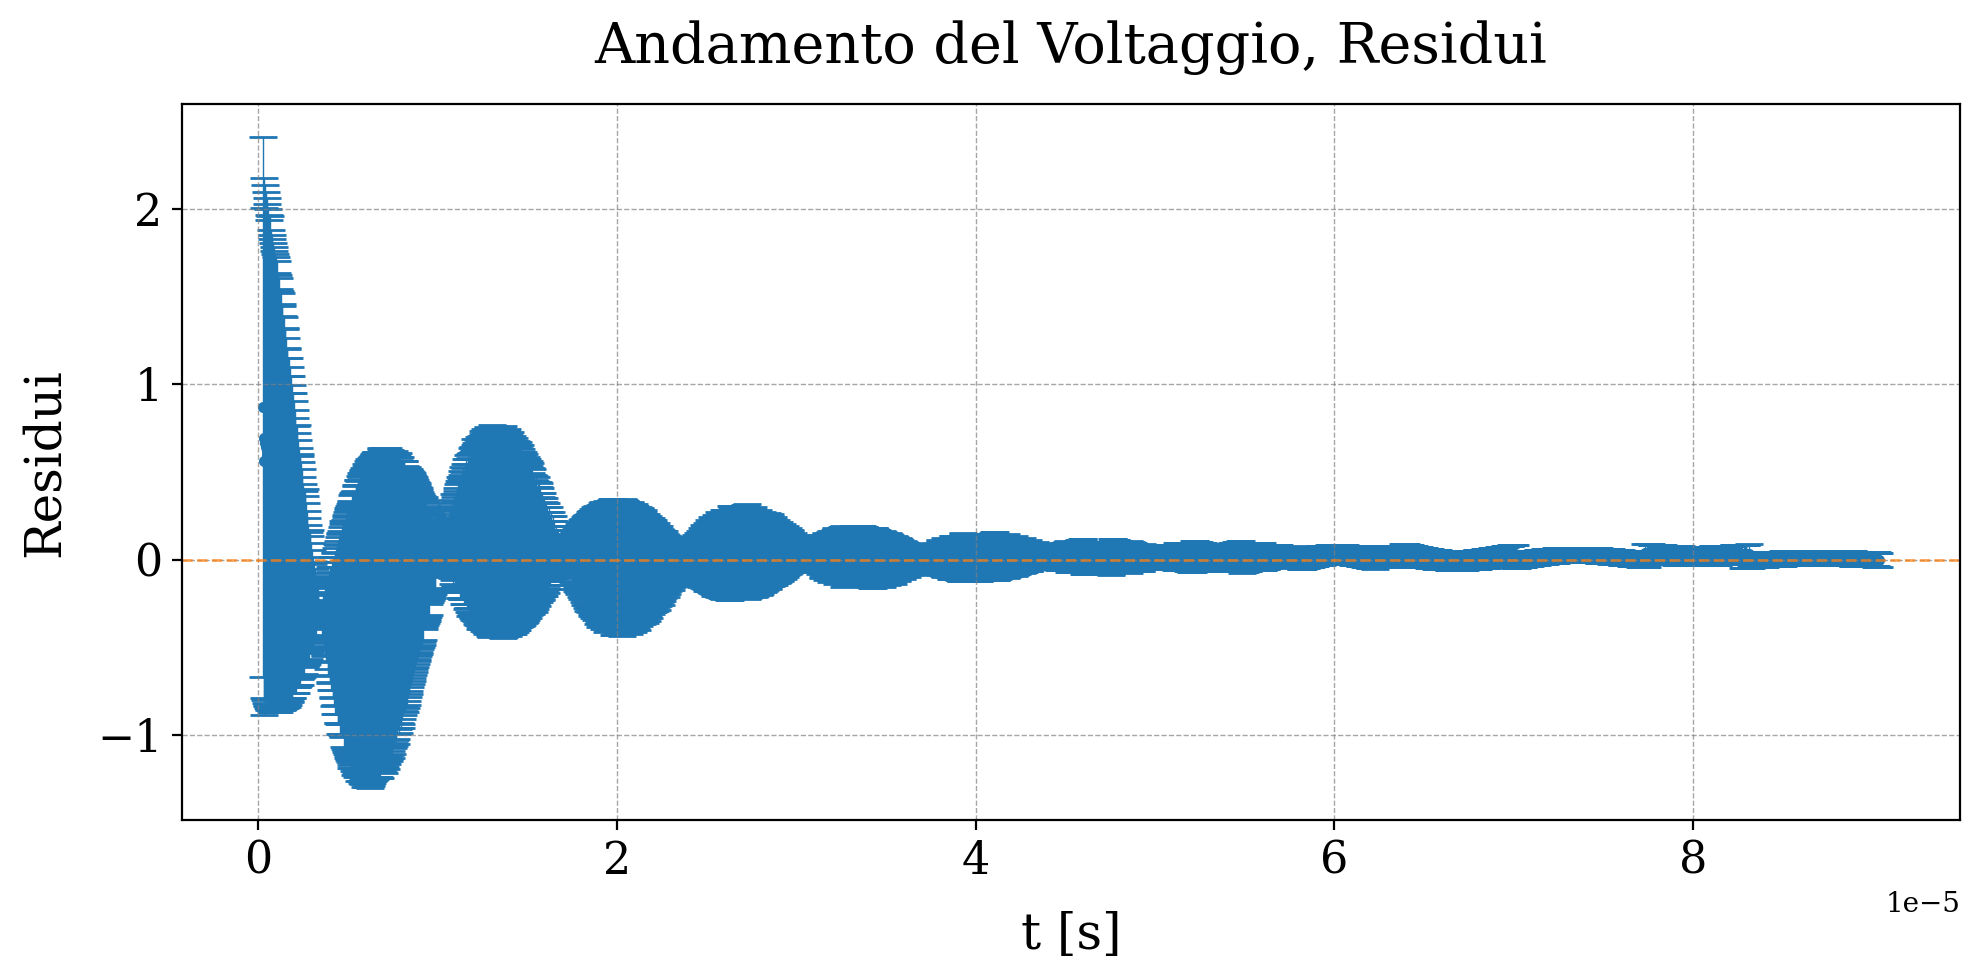

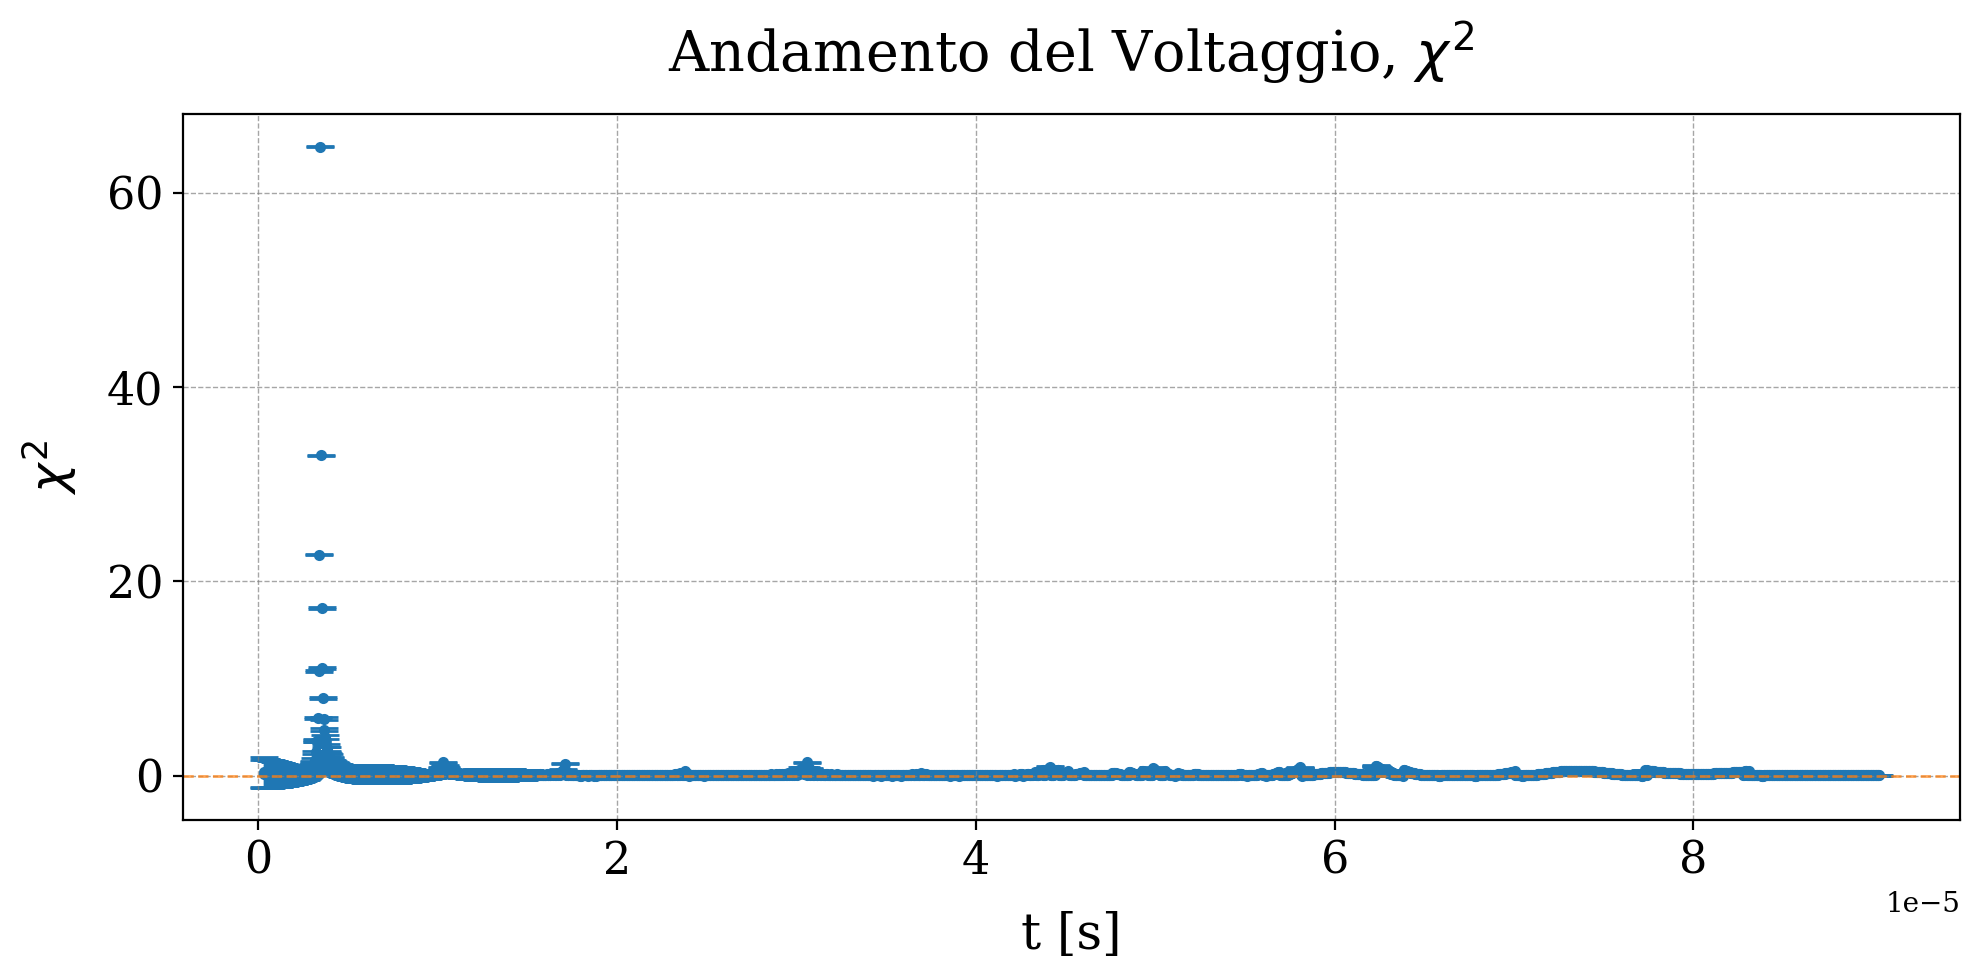

In [12]:
# Grafico dei residui
fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
gf.parametri_grafico(ax,titolo + ", Residui",xlabel=xlabel,ylabel="Residui")

ax.errorbar(res[0],res[1],yerr=res[2],
            **gf.errorbar_params, color=gf.colori[0], zorder = 1)
ax.axhline(0,
           **gf.line_params, color=gf.colori[1], zorder = 2)

gf.salva_grafico(fig,grafico_output2)

# Grafico chi quadro
fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
gf.parametri_grafico(ax,titolo + r", $\chi^2$",xlabel=xlabel,ylabel="$\chi^2$")

ax.errorbar(chi[0],chi[1],yerr=chi[2],
            **gf.errorbar_params, color=gf.colori[0], zorder = 1)
ax.axhline(0,
           **gf.line_params, color=gf.colori[1], zorder = 2)

gf.salva_grafico(fig,grafico_output3)